# Libraries Load

In [1]:
!pip install swig

In [2]:
!pip install gymnasium[box2d]

In [3]:
!pip install renderlab

# 2. Gymnasium Environment

  The reset() function is used to restart the environment, i.e. to restore the environment to its initial state.

  The step(action) function is the basic function of interaction with the environment. It accepts an action, executes it in the environment, and returns a new state/reward.

  Lastly, the render() function is used to visualize the environment.

# 3. LunarLander-v3 Environmnet

**The LunarLander-v3 environment** simulates the landing of a spacecraft on the Moon. The agent's goal is to land the spacecraft safely at a specific location using its engines.

*The observation space* is continuous and consists of the horizontal position of the spacecraft, the vertical position of the spacecraft, the horizontal velocity, the vertical velocity, angle of rotation of the spacecraft, angular velocity, left leg contact with the ground(0 or 1) and the right leg contact with the ground (0 or 1).

*Action Space* defines the actions that the agent can perform.

*The Reward Function* guides the agent's learning by rewarding or punishing specific behaviors.

# 4. Random Agent & Visualization with renderlab

In [4]:
import renderlab as rl
import gymnasium as gym
import random
import renderlab

In [6]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = rl.RenderFrame(env, "./output")

In [7]:
observation, info = env.reset()

In [8]:
while True:
  action = env.action_space.sample()
  observation, reward, terminated, truncated, info = env.step(action)

  if terminated or truncated:
    break

env.play()


Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


# 5. Random agent for 5 episodes & average score

In [9]:
import numpy as np

env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = rl.RenderFrame(env, "./output")

episodes = 5
scores = []

for ep in range(episodes):
    observation, info = env.reset()
    total_reward = 0

    while True:
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    scores.append(total_reward)
    print(f"Episode {ep+1} - Score: {total_reward:.2f}")

mean_score = np.mean(scores)
print("\nMean score random agent:", round(mean_score, 2))

env.play()

Episode 1 - Score: -369.93
Episode 2 - Score: -468.68
Episode 3 - Score: -126.70
Episode 4 - Score: -246.02
Episode 5 - Score: -98.78

Mean score random agent: -262.02
Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



t:  97%|█████████▋| 90/93 [00:00<00:00, 318.86it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file ./output/1768386803.7419324.mp4, 720000 bytes wanted but 0 bytes read,at frame 92/93, at time 3.07/3.07 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


# 6. Training with Stable Baselines

In [10]:
!pip install stable-baselines3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 14.2 MB/s eta 0:00:00


Training with DQN

In [11]:
from stable_baselines3 import DQN

env = gym.make("LunarLander-v3")

dqn_model = DQN(policy="MlpPolicy",env=env,learning_rate=1e-3,buffer_size=100000,batch_size=64,verbose=1)

dqn_model.learn(total_timesteps=100_000)

env.close()

  return datetime.utcnow().replace(tzinfo=utc)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


  return datetime.utcnow().replace(tzinfo=utc)



----------------------------------
| rollout/            |          |
|    ep_len_mean      | 104      |
|    ep_rew_mean      | -275     |
|    exploration_rate | 0.961    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 877      |
|    time_elapsed     | 0        |
|    total_timesteps  | 415      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 1.02     |
|    n_updates        | 78       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 95.2     |
|    ep_rew_mean      | -233     |
|    exploration_rate | 0.928    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 914      |
|    time_elapsed     | 0        |
|    total_timesteps  | 762      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 1.15     |
|    n_updates      

Training with PPO

In [12]:
from stable_baselines3 import PPO

env = gym.make("LunarLander-v3")

ppo_model = PPO(policy="MlpPolicy",env=env,learning_rate=3e-4,verbose=1)

ppo_model.learn(total_timesteps=100_000)

env.close()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 88.8     |
|    ep_rew_mean     | -166     |
| time/              |          |
|    fps             | 1169     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 96.6        |
|    ep_rew_mean          | -214        |
| time/                   |             |
|    fps                  | 874         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006798956 |
|    clip_fraction        | 0.0124      |
|    clip_range           | 0.2         |
|    entropy_loss   

# 7. Agent Evaluation & Comparison

In [13]:
import numpy as np

def evaluate_agent(model, env, episodes=5):
    rewards = []

    for _ in range(episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    return np.mean(rewards)

Average reward for each agent

In [14]:
import gymnasium as gym

env = gym.make("LunarLander-v3")
def random_agent_score(env, episodes=5):
    scores = []
    for _ in range(episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
        scores.append(total_reward)
    return np.mean(scores)

random_mean = random_agent_score(env)
dqn_mean = evaluate_agent(dqn_model, env)
ppo_mean = evaluate_agent(ppo_model, env)

print("Mean  reward Random:", round(random_mean, 2))
print("Mean reward DQN:", round(dqn_mean, 2))
print("Mean reward PPO:", round(ppo_mean, 2))

env.close()

Mean  reward Random: -295.68
Mean reward DQN: -103.9
Mean reward PPO: -172.73


Training Time

In [15]:
import time
start = time.time()
dqn_model.learn(total_timesteps=100_000)
dqn_time = time.time() - start

start = time.time()
ppo_model.learn(total_timesteps=100_000)
ppo_time = time.time() - start

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 106      |
|    ep_rew_mean      | -176     |
|    exploration_rate | 0.96     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1589     |
|    time_elapsed     | 0        |
|    total_timesteps  | 422      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.761    |
|    n_updates        | 25055    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 92.5     |
|    ep_rew_mean      | -168     |
|    exploration_rate | 0.93     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1470     |
|    time_elapsed     | 0        |
|    total_timesteps  | 740      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.269    |
|    n_updates      

Plots

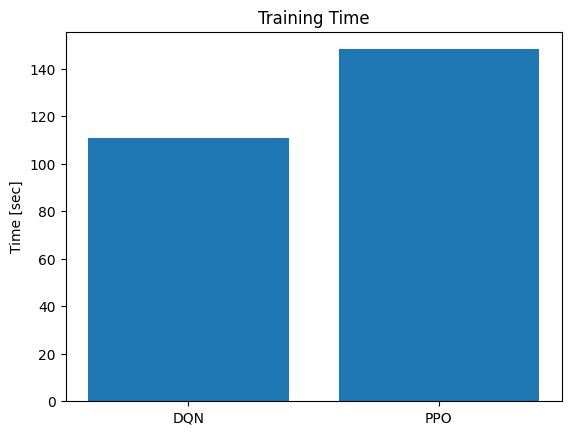

In [16]:
import matplotlib.pyplot as plt

agents = ["DQN", "PPO"]
times = [dqn_time, ppo_time]

plt.bar(agents, times)
plt.title("Training Time")
plt.ylabel("Time [sec]")
plt.show()